# Simulation of Michaelis-Menten Kinetics

**Bintang Adhitya Kuncoro Putra**
**Komputasi Biologi**
**23/518604/TK/57118**

This notebook is a companion piece to *Simple Networks - MMSB Section 2.1.3*. It tells the story of one of the most famous equations in biology, the Michaelis-Menten rate law, by *building* it from scratch instead of just handing it to you.

## What Are We Simulating?

Think of an **enzyme** ($E$) as a tiny helper molecule. It doesn't get used up; it just makes a chemical reaction happen faster. It does this by grabbing onto a **substrate** ($S$) - the molecule that's about to be transformed - and holding onto it for a moment as an **enzyme-substrate complex** ($C$). Once the transformation is done, the complex falls apart into the finished **product** ($P$), and the enzyme is released, unchanged, ready to grab the next substrate molecule.

You've probably already seen the famous rate law for how fast this reaction goes:

$$
v=\frac{V_{\max}[S]}{K_m+[S]} .
$$

That equation is not where the story starts - it's the *ending*. Before we get anywhere near it, we need to answer a much more basic question:

> **How do we turn "enzyme grabs substrate, then lets go of product" into equations a computer can actually simulate?**

That's what this notebook works out, one small step at a time.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


## 1. From "What Happens" to "How Fast It Happens"

Written as a single diagram, the enzyme story looks like this:

$$
S+E \underset{k_r}{\overset{k_f}{\rightleftharpoons}} C \overset{k_2}{\longrightarrow} P+E .
$$

The double arrow between $S+E$ and $C$ just means "binding can happen, but so can un-binding" - like a handshake that either turns into something more, or just lets go. To simulate this, we split it into three separate, one-directional steps, each with its own speed dial (a **rate constant**):

- **binding**: $S+E\xrightarrow{k_f}C$ - substrate and enzyme find each other and stick.
- **un-binding**: $C\xrightarrow{k_r}S+E$ - they let go before anything happens.
- **catalysis**: $C\xrightarrow{k_2}P+E$ - the enzyme finishes the job and frees itself.

Common sense (formalized as the **Law of Mass Action**) says: the more of the ingredients are floating around, the more often they bump into each other and react. Binding needs *both* substrate and free enzyme, so its rate depends on both:

$$
v_f=k_fSE, \qquad v_r=k_rC, \qquad v_2=k_2C .
$$

$v_r$ and $v_2$ only depend on $C$, because un-binding and catalysis just need an existing complex to fall apart - nothing else is required.


## 2. From "How Fast" to "How Much Changes"

Knowing $v_f$, $v_r$, $v_2$ tells us how fast each step fires, but not yet how much $S$, $E$, $C$, or $P$ actually changes. For that we ask, one species at a time: *which steps add to it, which steps take away from it?*

**Substrate $S$.** Binding uses up one $S$ ($-v_f$). Un-binding gives one back ($+v_r$). Catalysis never touches $S$ directly ($0$). Adding these up:

$$
\frac{dS}{dt}=-v_f+v_r .
$$

**Complex $C$.** Binding creates one $C$ ($+v_f$). Un-binding destroys one ($-v_r$). Catalysis also destroys one, by turning it into product ($-v_2$):

$$
\frac{dC}{dt}=v_f-v_r-v_2 .
$$

**Product $P$.** Only catalysis makes $P$ ($+v_2$); nothing else touches it:

$$
\frac{dP}{dt}=v_2 .
$$

**Enzyme $E$.** This is the one that's easy to get wrong. Binding uses up one free $E$ ($-v_f$). But $E$ comes back in *two* different ways: if the complex simply falls apart again (un-binding, $+v_r$), *and* if the complex finishes the reaction (catalysis, $+v_2$) - because catalysis releases the enzyme too, not just the product.

$$
\frac{dE}{dt}=-v_f+v_r+v_2 .
$$

Now substitute $v_f=k_fSE$, $v_r=k_rC$, $v_2=k_2C$ into all four lines, and we have a genuine system of differential equations - the **full, four-variable model**:

$$
\boxed{
\begin{aligned}
\dot S&=-k_fSE+k_rC\\
\dot E&=-k_fSE+k_rC+k_2C\\
\dot C&=k_fSE-k_rC-k_2C\\
\dot P&=k_2C
\end{aligned}}
$$


## 3. Writing the Full Model in Python

Every line of `dydt` below is simply one of the four boxed equations above, written in Python instead of math symbols. The parameter values ($k_f=30$, $k_r=1$, $k_2=10$, $e_T=1$) and starting amounts ($S_0=5$, $C_0=0$, $P_0=0$) are the same ones used in the course slides.


In [ ]:
# set parameters
kf = 30      # binding rate constant:    S + E -> C
kr = 1       # un-binding rate constant: C -> S + E
k2 = 10      # catalysis rate constant:  C -> P + E
et = 1       # total enzyme, E0 + C0

def network_full(y, t):
    # create container
    dydt = np.empty(4)

    # set dynamic variables
    s = y[0]
    e = y[1]
    c = y[2]
    p = y[3]

    # differential equations
    dydt[0] = -kf*s*e + kr*c              # dS/dt
    dydt[1] = -kf*s*e + kr*c + k2*c       # dE/dt  (the +k2*c is catalysis freeing the enzyme)
    dydt[2] =  kf*s*e - kr*c - k2*c       # dC/dt
    dydt[3] =  k2*c                       # dP/dt

    return dydt


In [ ]:
# set initial condition
init = [5, et, 0, 0]     # [S0, E0, C0, P0]  -- E0 = et, since no complex has formed yet

# set time points
t = np.linspace(0, 1, 300)

# solve equations
y_full = odeint(network_full, init, t)   # solve ODE
S_full, E_full, C_full, P_full = y_full[:, 0], y_full[:, 1], y_full[:, 2], y_full[:, 3]


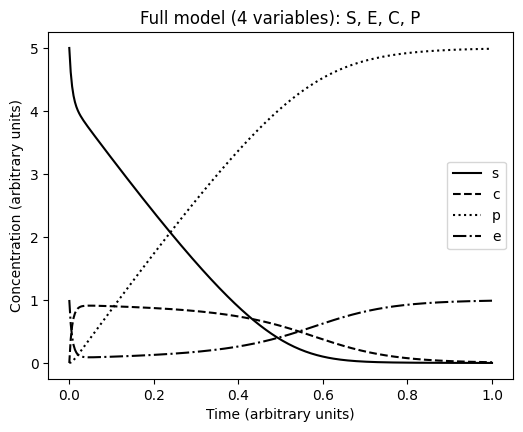

In [ ]:
plt.figure(figsize=(6, 4.5))
plt.plot(t, S_full, "-",  color="black", label="s")
plt.plot(t, C_full, "--", color="black", label="c")
plt.plot(t, P_full, ":",  color="black", label="p")
plt.plot(t, E_full, "-.", color="black", label="e")
plt.xlabel("Time (arbitrary units)")
plt.ylabel("Concentration (arbitrary units)")
plt.title("Full model (4 variables): S, E, C, P")
plt.legend()
plt.show()


**Reading this graph.** $S$ (solid) starts at $5$ and drops fast, because binding is quick ($k_f=30$). $C$ (dashed) shoots up almost immediately as complex forms, then slowly drains away as substrate runs out. $P$ (dotted) climbs steadily and levels off near $5$, once nearly all the substrate has been converted. $E$ (dash-dot) starts at $1$, dips down while enzyme is tied up in complexes, then climbs back toward $1$ as the complexes finish their work and let the enzyme go.


## 4. A Question the Model Answers for Free: Is Enzyme Ever Lost?

Before changing anything, let's ask the model a question using nothing but algebra: does it ever create or destroy enzyme out of nowhere? Add the $\dot E$ and $\dot C$ equations together:

$$
\frac{d}{dt}(E+C)=\dot E+\dot C
=\big(-k_fSE+k_rC+k_2C\big)+\big(k_fSE-k_rC-k_2C\big) .
$$

Look at the right-hand side term by term: $-k_fSE$ cancels with $+k_fSE$, $+k_rC$ cancels with $-k_rC$, and $+k_2C$ cancels with $-k_2C$. Everything cancels, leaving

$$
\frac{d}{dt}(E+C)=0 .
$$

A rate of change equal to zero means the quantity never moves, so $E(t)+C(t)$ stays exactly constant, forever:

$$
E(t)+C(t)=E_0+C_0\equiv e_t \quad\text{for every }t .
$$

In plain words: an enzyme molecule is always in one of exactly two "rooms" - free, or holding hands with a substrate as part of a complex. It never leaves those two rooms, so the total count never changes.


## 5. Why Bother Simplifying?

The relationship we just found, $E+C=e_t$, means something very specific: **if you know $C$ at any moment, you already know $E$ too** - just compute $e_t-C$. There's no new information hiding in $E$ that isn't already implied by $C$.

That has a concrete, practical consequence. Right now `network_full` carries four numbers ($S,E,C,P$) at every time step, even though one of them, $E$, could always be recomputed from another. It's a bit like keeping a spreadsheet column for "seats still empty" *and* a separate column for "seats filled," when you already know the room's total capacity - one column is always just arithmetic away from the other. It's extra work, and it's a second place where a typo could quietly break the bookkeeping.

So the real reason to simplify isn't "four numbers is scary." It's: **we are tracking one piece of information twice, and we don't have to.**

$$
4\ \text{states} \;\longrightarrow\; 3\ \text{states} .
$$

To be clear about what this is and isn't: we are **not** deciding the enzyme doesn't matter, or that its amount barely changes. The enzyme is still fully accounted for at every instant, through $E=e_t-C$. We've only stopped storing it as its own separate variable, because it was redundant.


## 6. Building the Reduced, Three-Variable Model, Step by Step

We now go back to the full equations and replace every $E$ with $e_t-C$, one line at a time.

**Start with $\dot S$:**

$$
\dot S=-k_fSE+k_rC .
$$

Substitute $E=e_t-C$:

$$
\dot S=-k_fS(e_t-C)+k_rC .
$$

**Start with $\dot C$:**

$$
\dot C=k_fSE-k_rC-k_2C .
$$

Substitute $E=e_t-C$:

$$
\dot C=k_fS(e_t-C)-k_rC-k_2C .
$$

**And $\dot P$** doesn't contain $E$ at all, so it doesn't change:

$$
\dot P=k_2C .
$$

Notice that $\dot E$ has completely disappeared - we don't need it any more, because whenever a rate term needs to know the free-enzyme amount, it can just compute $e_t-C$ on the spot. Collecting the three surviving equations gives the **reduced model**:

$$
\boxed{
\begin{aligned}
\frac{dS}{dt}&=-k_fS(e_t-C)+k_rC\\[2pt]
\frac{dC}{dt}&=k_fS(e_t-C)-k_rC-k_2C\\[2pt]
\frac{dP}{dt}&=k_2C
\end{aligned}}
$$

Nothing about the chemistry changed - the enzyme still binds, un-binds, and catalyzes exactly as before. All that changed is *how we describe* the system: three tracked numbers instead of four, with $E$ pulled out only when it's actually needed.


In [ ]:
def network_reduced(y, t):
    # create container
    dydt = np.empty(3)

    # set dynamic variables
    s = y[0]
    c = y[1]
    p = y[2]
    e = et - c                            # E is recovered here, not tracked as its own state

    # differential equations
    dydt[0] = -kf*s*e + kr*c              # dS/dt
    dydt[1] =  kf*s*e - kr*c - k2*c       # dC/dt
    dydt[2] =  k2*c                       # dP/dt

    return dydt


In [ ]:
# set initial condition
init = [5, 0, 0]     # [S0, C0, P0]

# set time points
t = np.linspace(0, 1, 300)

# solve equations
y_reduced = odeint(network_reduced, init, t)   # solve ODE
S_red, C_red, P_red = y_reduced[:, 0], y_reduced[:, 1], y_reduced[:, 2]
E_red = et - C_red     # recovered afterwards, purely for plotting/checking


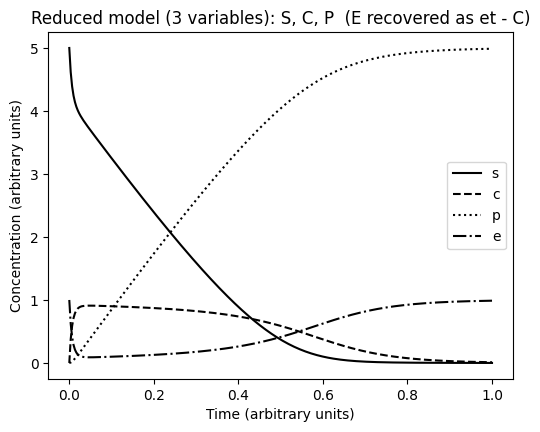

In [ ]:
plt.figure(figsize=(6, 4.5))
plt.plot(t, S_red, "-",  color="black", label="s")
plt.plot(t, C_red, "--", color="black", label="c")
plt.plot(t, P_red, ":",  color="black", label="p")
plt.plot(t, E_red, "-.", color="black", label="e")
plt.xlabel("Time (arbitrary units)")
plt.ylabel("Concentration (arbitrary units)")
plt.title("Reduced model (3 variables): S, C, P  (E recovered as et - C)")
plt.legend()
plt.show()


This looks like the exact same picture as the full model's graph in Section 3 - which is exactly what we'd hope for, since Section 6 showed that the two models describe the same chemistry.


## 7. One Last Check: Do the Numbers Really Agree?

We just built two versions of the same reaction: one that keeps $E$ as its own tracked number (`network_full`), and one that computes it on the spot instead ($E=e_t-C$, in `network_reduced`). Section 6 showed on paper that they should behave identically. Let's actually check, instead of just assuming it.

First, two quick checks that should always hold, for either model:


In [ ]:
enzyme_total = E_full + C_full
print(f"Enzyme total, full model:      start = {enzyme_total[0]:.4f}, end = {enzyme_total[-1]:.4f}  (should stay at et = {et})")

mass_full = S_full + C_full + P_full
mass_red  = S_red  + C_red  + P_red
print(f"S+C+P, full model:             start = {mass_full[0]:.4f}, end = {mass_full[-1]:.4f}")
print(f"S+C+P, reduced model:          start = {mass_red[0]:.4f}, end = {mass_red[-1]:.4f}")


Enzyme total, full model:      start = 1.0000, end = 1.0000  (should stay at et = 1)
S+C+P, full model:             start = 5.0000, end = 5.0000
S+C+P, reduced model:          start = 5.0000, end = 5.0000


Now the direct check: how far apart are the two models' curves, at their worst point in time?


In [ ]:
diff_S = np.max(np.abs(S_full - S_red))
diff_C = np.max(np.abs(C_full - C_red))
diff_P = np.max(np.abs(P_full - P_red))
print(f"Biggest gap between the two models:  S: {diff_S:.2e}   C: {diff_C:.2e}   P: {diff_P:.2e}")


Biggest gap between the two models:  S: 6.79e-08   C: 5.90e-08   P: 7.22e-08


Numbers are convincing, but a picture is more convincing. Let's overlay the two models directly: solid line = full model, dashed line = reduced model, one color per species. If they really are "the same reaction, described more economically," the dashed line should sit exactly on top of the solid line of the same color.


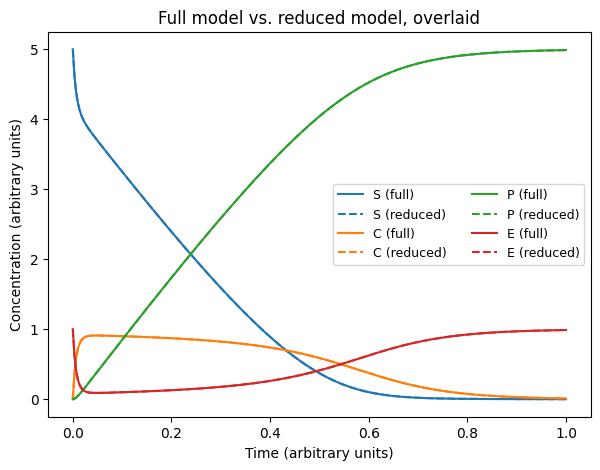

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(t, S_full, "-",  color="tab:blue",   label="S (full)")
plt.plot(t, S_red,  "--", color="tab:blue",   label="S (reduced)")

plt.plot(t, C_full, "-",  color="tab:orange", label="C (full)")
plt.plot(t, C_red,  "--", color="tab:orange", label="C (reduced)")

plt.plot(t, P_full, "-",  color="tab:green",  label="P (full)")
plt.plot(t, P_red,  "--", color="tab:green",  label="P (reduced)")

plt.plot(t, E_full, "-",  color="tab:red",    label="E (full)")
plt.plot(t, E_red,  "--", color="tab:red",    label="E (reduced)")

plt.xlabel("Time (arbitrary units)")
plt.ylabel("Concentration (arbitrary units)")
plt.title("Full model vs. reduced model, overlaid")
plt.legend(ncol=2, fontsize=9)
plt.show()


The gap is tiny - around $10^{-8}$, meaning a decimal point followed by seven zeros before the first real digit. It is small enough to be invisible on a graph, but it is worth knowing where it comes from, because it isn't exactly zero:

- **On paper, the two models are identical.** Section 4 proved $E+C=e_t$ holds exactly, at every instant. So the *true* mathematical answer is the same curve either way.
- **The computer isn't perfectly precise.** `odeint` doesn't solve the equations exactly - it takes small steps forward and approximates, accepting a tiny bit of rounding error at each step. The full model (four numbers to update each step) and the reduced model (three numbers) take slightly different paths through that approximation, which is the entire source of the small gap above.
- **This is a good sign, not a bad one.** If the gap had been large, that would mean something was actually wrong - a missing term, a typo, or inconsistent starting values. Because the gap is this small, it confirms that Section 6's algebra was done correctly, and that the reduced model really is "the same reaction, described more economically," not a different, approximate one.


## 8. Recap

Here's the path we walked, from a plain description of an enzyme's job to a working, checked simulation:

```
what an enzyme does (in words)
        |
split into 3 one-way reactions
        |
Law of Mass Action  ->  reaction rates
        |
who gains/loses what  ->  full 4-variable ODE system
        |
add up dE/dt + dC/dt  ->  enzyme conservation, E + C = et
        |
recognize E is redundant  ->  reduced 3-variable ODE system
        |
simulate both  ->  sanity checks  ->  the numbers agree
```

At no point did we need to *assume* anything was slow, fast, or basically constant - every step from the full model to the reduced model was exact algebra, and the simulation double-checked its own work.

**Reference:** Ingalls, B. P. (2013). *Mathematical Modeling in Systems Biology: An Introduction*. MIT Press. Chapter 2, Section 2.1.3.
